In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Illustration 9.6-1 and Figure 9.6-1 &mdash; regular solution theory

This notebook reproduces **Illustration 9.6-1** and **Figure 9.6-1** for benzene /
2,2,4-trimethyl pentane, the second of three notebooks on one system.

The correlative models of the previous notebook were *fitted* to these data. Regular
solution theory **predicts** them from pure-component properties alone &mdash; molar
liquid volumes and solubility parameters &mdash; with no mixture measurement anywhere in
the calculation.

That is its appeal, and Illustration 9.6-1 is the book's own warning about the price.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from thermo.charts import use_book_style
use_book_style()
R = constants.R

In [3]:
# Weissman and Wood, benzene(B)/2,2,4-trimethyl pentane(TMP) at 55 C -- SIS
# Illustration 10.2-4. The same seven points the correlation notebook uses.
T = 328.15
xB    = np.array([0.0819, 0.2192, 0.3584, 0.3831, 0.5256, 0.8478, 0.9872])
yB    = np.array([0.1869, 0.4065, 0.5509, 0.5748, 0.6786, 0.8741, 0.9863])
P_bar = np.array([0.26892, 0.31573, 0.35463, 0.36088, 0.39105, 0.43277, 0.43641])
Pvap_B, Pvap_TMP = 0.43596, 0.23738
gB = yB * P_bar / (xB * Pvap_B)
gT = (1 - yB) * P_bar / ((1 - xB) * Pvap_TMP)

## The model

$$RT\ln\gamma_i = \underline{V}_i\,(\delta_i - \bar\delta)^2
\qquad \bar\delta = \sum_j \Phi_j \delta_j
\qquad \Phi_i = \frac{x_i \underline{V}_i}{\sum_j x_j \underline{V}_j}
\tag{Eqs. 9.6-8 to 9.6-11}$$

⚠️ **$\Phi_i$ here is not the $\phi_i$ of UNIQUAC.** Both are called the volume fraction
of species $i$, but this one is built from molar volumes and the other from the group
volume parameter $r_i$. The chapter keeps both symbols, distinguished only by case.

Table 9.6-1 gives $\underline{V}^L$ in cc/mol and $\delta$ in (cal/cc)$^{1/2}$ and says in
its own note that it keeps those units by tradition. `from_table_9_6_1` takes them as
printed and converts to SI, so the arithmetic happens in J/mol.

In [4]:
from thermo import RegularSolution
from thermo.activity_models import TABLE_9_6_1

print("Table 9.6-1 gives benzene but not 2,2,4-trimethyl pentane:")
print("  benzene:", TABLE_9_6_1["benzene"], "(V^L cc/mol, delta (cal/cc)^1/2)")
print("  2,2,4-trimethyl pentane:", TABLE_9_6_1.get("2,2,4-trimethyl pentane", "-- not in the table"))

Table 9.6-1 gives benzene but not 2,2,4-trimethyl pentane:
  benzene: (89.0, 9.2) (V^L cc/mol, delta (cal/cc)^1/2)
  2,2,4-trimethyl pentane: -- not in the table


Illustration 9.6-1 fills the gap the way the model intends: the solubility parameter
is a *pure-component* quantity, so it can be estimated from the enthalpy of
vaporization,

$$\delta = \left(\frac{\Delta_{\rm vap}\underline{U}}{\underline{V}^L}\right)^{1/2}
        = \left(\frac{\Delta_{\rm vap}\underline{H} - RT}{\underline{V}^L}\right)^{1/2}$$

neglecting the liquid molar volume against the vapor's and assuming an ideal vapor.
The book takes $\underline{V}^L \approx 165$ cc/mol and $\Delta_{\rm vap}\underline{H}$
from Illustration 7.7-1, and gets $\delta = 6.93$ (cal/cc)$^{1/2}$.

In [5]:
from thermo.activity_models import CAL_CC_HALF, CC_PER_MOL

V_TMP = 165 * CC_PER_MOL                       # m^3/mol
delta_book = 6.93                              # (cal/cc)^1/2, the book's answer
# what enthalpy of vaporization does that imply?
dHvap = (delta_book * CAL_CC_HALF)**2 * V_TMP + R * 298.15
print(f"delta = 6.93 (cal/cc)^1/2 corresponds to dHvap = {dHvap/1000:.1f} kJ/mol at 25 C")
print("recovering it:",
      f"{RegularSolution.delta_from_vaporization(dHvap, V_TMP, 298.15)/CAL_CC_HALF:.2f} (cal/cc)^1/2")

rs = RegularSolution.from_table_9_6_1([89, 165], [9.2, delta_book])   # benzene, TMP
print("\nSI parameters actually used:")
print(f"  V     = {rs.V} m^3/mol")
print(f"  delta = {np.round(rs.delta, 1)} Pa^(1/2)")

delta = 6.93 (cal/cc)^1/2 corresponds to dHvap = 35.6 kJ/mol at 25 C
recovering it: 6.93 (cal/cc)^1/2

SI parameters actually used:
  V     = [8.90e-05 1.65e-04] m^3/mol
  delta = [18818.4 14175.2] Pa^(1/2)


## The prediction against the data

In [6]:
print(f"{'xB':>8}{'RS gB':>9}{'exp gB':>9}   {'RS gTMP':>9}{'exp gTMP':>10}")
for i, a in enumerate(xB):
    g = rs.gamma([a, 1-a], T)
    print(f"{a:8.4f}{g[0]:9.3f}{gB[i]:9.3f}   {g[1]:9.3f}{gT[i]:10.3f}")

      xB    RS gB   exp gB     RS gTMP  exp gTMP
  0.0819    1.897    1.408       1.003     1.003
  0.2192    1.700    1.343       1.023     1.011
  0.3584    1.515    1.250       1.072     1.046
  0.3831    1.484    1.242       1.086     1.048
  0.5256    1.317    1.158       1.200     1.116
  0.8478    1.045    1.023       2.083     1.508
  0.9872    1.000    1.000       3.467     1.968


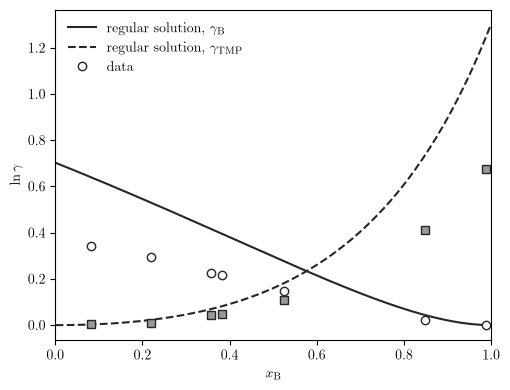

In [7]:
# The book plots ln gamma, not gamma (Figs. 9.5-4, 9.5-5, 9.6-1, 9.6-2 all do), and
# so does the correlation notebook this one is compared against. Same ordinate here.
x = np.linspace(0.001, 0.999, 400)
g = np.array([rs.gamma([a, 1-a], T) for a in x])
fig, ax = plt.subplots(figsize=(5.2, 4))
ax.plot(x, np.log(g[:,0]), "-",  color="0.15", label=r"regular solution, $\gamma_{\mathrm{B}}$")
ax.plot(x, np.log(g[:,1]), "--", color="0.15", label=r"regular solution, $\gamma_{\mathrm{TMP}}$")
ax.plot(xB, np.log(gB), "o", mfc="white", color="0.15", label="data")
ax.plot(xB, np.log(gT), "s", mfc="0.6",  color="0.15")
ax.set_xlabel(r"$x_{\mathrm{B}}$"); ax.set_ylabel(r"$\ln\gamma$")
ax.set_xlim(0, 1); ax.legend(frameon=False)
fig.tight_layout()

In [8]:
# --- Print art: Figure 9.6-1 -----------------------------------------------
# Stage as deliverables/figures/print-bw/ch9/c09f007.pdf
#
# Redrawn to the printed figure's own conventions, checked against the 5e art
# (c09f007.jpg): ordinate is ln(gamma); the two curves are labeled ON the curves
# as gamma_B and gamma_TMP; and there is NO legend.
#
# TWO marker styles for the data -- open circles for benzene, filled squares for
# 2,2,4-trimethyl pentane. This is a DELIBERATE departure from the 5e art, which
# uses one marker for both species: with two curves crossing, keying the points to
# their species makes the figure markedly easier to read and costs nothing in black
# and white. The caption should say which marker is which.
import os
os.makedirs("pdf", exist_ok=True)

lnB, lnT = np.log(g[:, 0]), np.log(g[:, 1])

f, a = plt.subplots(figsize=(5.0, 3.8))
a.plot(x, lnB, "-", color="0.15")
a.plot(x, lnT, "-", color="0.15")
a.plot(xB, np.log(gB), "o", mfc="white", color="0.15")
a.plot(xB, np.log(gT), "s", mfc="0.6",  color="0.15")
a.set_xlabel(r"$x_{\mathrm{B}}$"); a.set_ylabel(r"$\ln\gamma$")
a.set_xlim(0, 1)
BOT, top = 0.0, 1.10 * max(lnB.max(), lnT.max())
a.set_ylim(BOT, top)

span = top - BOT
a.text(0.16, np.interp(0.16, x, lnB) + 0.05 * span,
       r"$\gamma_{\mathrm{B}}$", ha="center", va="bottom")
a.text(0.80, np.interp(0.80, x, lnT) - 0.05 * span,
       r"$\gamma_{\mathrm{TMP}}$", ha="center", va="top")

f.tight_layout()
f.savefig("pdf/Fig_9.6-1.pdf", dpi=300, bbox_inches="tight")
plt.close(f)
print("wrote pdf/Fig_9.6-1.pdf")

wrote pdf/Fig_9.6-1.pdf


## Two things the model cannot do, and one of them is structural

The agreement is *qualitatively* right — both activity coefficients exceed one and rise
with dilution — and quantitatively poor, as Illustration 9.6-1 says. At infinite
dilution the prediction is roughly twice the measured departure from ideality.

The second limitation is not a matter of accuracy:

In [9]:
grid = np.linspace(0.001, 0.999, 199)
mn = min(rs.gamma([a, 1-a], T).min() for a in grid)
print(f"smallest activity coefficient anywhere in the composition range: {mn:.4f}")
print("regular solution theory can never predict gamma < 1 --")
print("(delta_i - deltabar)^2 is a square, so RT ln gamma_i >= 0 always.")

smallest activity coefficient anywhere in the composition range: 1.0000
regular solution theory can never predict gamma < 1 --
(delta_i - deltabar)^2 is a square, so RT ln gamma_i >= 0 always.


**It can only describe positive deviations from ideality.** A mixture with
$\gamma_i < 1$ — and Sec. 9.11 lists several classes — is outside the model by
construction, not by a bad parameter. Section 9.6 makes the same point from the
underlying assumption: Eq. 9.6-7 forces $(\Delta_{\rm vap}\underline{U})_{\rm mix}$ to lie
between the two pure-component values.

⭐ **This is the book's own warning, and it is worth taking literally**: *"theoretical
predictions may not always be accurate and … experimental data are to be preferred."*
The next notebook asks whether a better theory does better.

**Your turn.** Table 9.6-1 gives both $\underline{V}^L$ and $\delta$ for benzene and
cyclohexane. Predict their activity coefficients at 25 °C, then look up an experimental
value. Does regular solution theory do better for two molecules of similar size and
polarity than it did here?